# Exploring Data Structure: Xenium OVCA dataset
Downloaded from: https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-ovarian-cancer

In [1]:
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt




In [2]:
# combining h5 and parquet into anndata
base = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full'

# load from h5
adata = sc.read_10x_h5(f'{base}/cell_feature_matrix.h5')

# load spatial coordinates
positions = pd.read_parquet(f'{base}/cells.parquet')
positions.index = positions['cell_id']

# # filter to only cells in adata and add coordinates
positions = positions.loc[adata.obs_names]
adata.obsm['spatial'] = positions[['x_centroid', 'y_centroid']].values

print(adata)
print("spatial coords first 3:", adata.obsm['spatial'][:3])

adata.write_h5ad("/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_full.h5ad")

AnnData object with n_obs × n_vars = 407124 × 5101
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
spatial coords first 3: [[ 540.86462402 4230.24707031]
 [ 532.86071777 4242.91992188]
 [ 527.63989258 4240.64941406]]


In [3]:
adata_full = sc.read_h5ad("/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_full.h5ad")
adata_crop = sc.read_h5ad("/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/tutadata_subset.h5ad")

import tifffile

image_crop_path = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/wsi_crop.ome.tif'
image_full_path = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_he_image.ome.tif'

with tifffile.TiffFile(image_crop_path) as tif:
    wsi_crop = tif.series[0].asarray()

with tifffile.TiffFile(image_full_path) as tif:
    wsi_full = tif.series[0].asarray()
 

In [4]:
# basic info
print("=== FULL ===")
print(adata_full)
print(adata_full.obs.columns.tolist())
print(adata_full.obsm.keys())

print("\n=== CROP ===")
print(adata_crop)
print(adata_crop.obs.columns.tolist())
print(adata_crop.obsm.keys())

# image shapes
print(f"\nFull image shape: {wsi_full.shape}")
print(f"Crop image shape: {wsi_crop.shape}")

# coordinate ranges
import numpy as np
coords_full = adata_full.obsm['spatial']
coords_crop = adata_crop.obsm['spatial']

print(f"\nFull coords x: {coords_full[:,0].min():.0f} - {coords_full[:,0].max():.0f}")
print(f"Full coords y: {coords_full[:,1].min():.0f} - {coords_full[:,1].max():.0f}")
print(f"Crop coords x: {coords_crop[:,0].min():.0f} - {coords_crop[:,0].max():.0f}")
print(f"Crop coords y: {coords_crop[:,1].min():.0f} - {coords_crop[:,1].max():.0f}")

=== FULL ===
AnnData object with n_obs × n_vars = 407124 × 5101
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
[]
KeysView(AxisArrays with keys: spatial)

=== CROP ===
AnnData object with n_obs × n_vars = 46691 × 5101
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'minor_celltype', 'major_celltype', 'cell_id', 'X_coord', 'Y_coord'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'wsi_crop'
    obsm: 'spatial', 'spatial_he'
['transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'min

In [5]:
# adding cell types to adata_full
cell_groups = pd.read_csv(
    "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/cell_groups.csv"
)

# set index for merging
cell_groups = cell_groups.set_index('cell_id')

# add to adata_full.obs
adata_full.obs['cell_type'] = cell_groups['group'].reindex(adata_full.obs_names)
adata_full.obs['cell_type_color'] = cell_groups['color'].reindex(adata_full.obs_names)

# check
print(adata_full.obs['cell_type'].value_counts())
print(f"\nCells with no label: {adata_full.obs['cell_type'].isna().sum()}")

cell_type
Tumor Cells                             103607
Smooth Muscle Cells                      61545
Proliferative Tumor Cells                50118
SOX2-OT+ Tumor Cells                     39355
Tumor Associated Fibroblasts             39332
Macrophages                              27415
Stromal Associated Fibroblasts           24604
Stromal Associated Endothelial Cells     18249
VEGFA+ Tumor Cells                       10088
T and NK Cells                            9999
Pericytes                                 4828
Tumor Associated Endothelial Cells        3813
Fallopian Tube Epithelium                 3034
Malignant Cells Lining Cyst               2534
Inflammatory Tumor Cells                  2158
Ciliated Epithelial Cells                 1987
Unassigned                                1984
Urothelial-like Cells                     1961
Name: count, dtype: int64

Cells with no label: 513


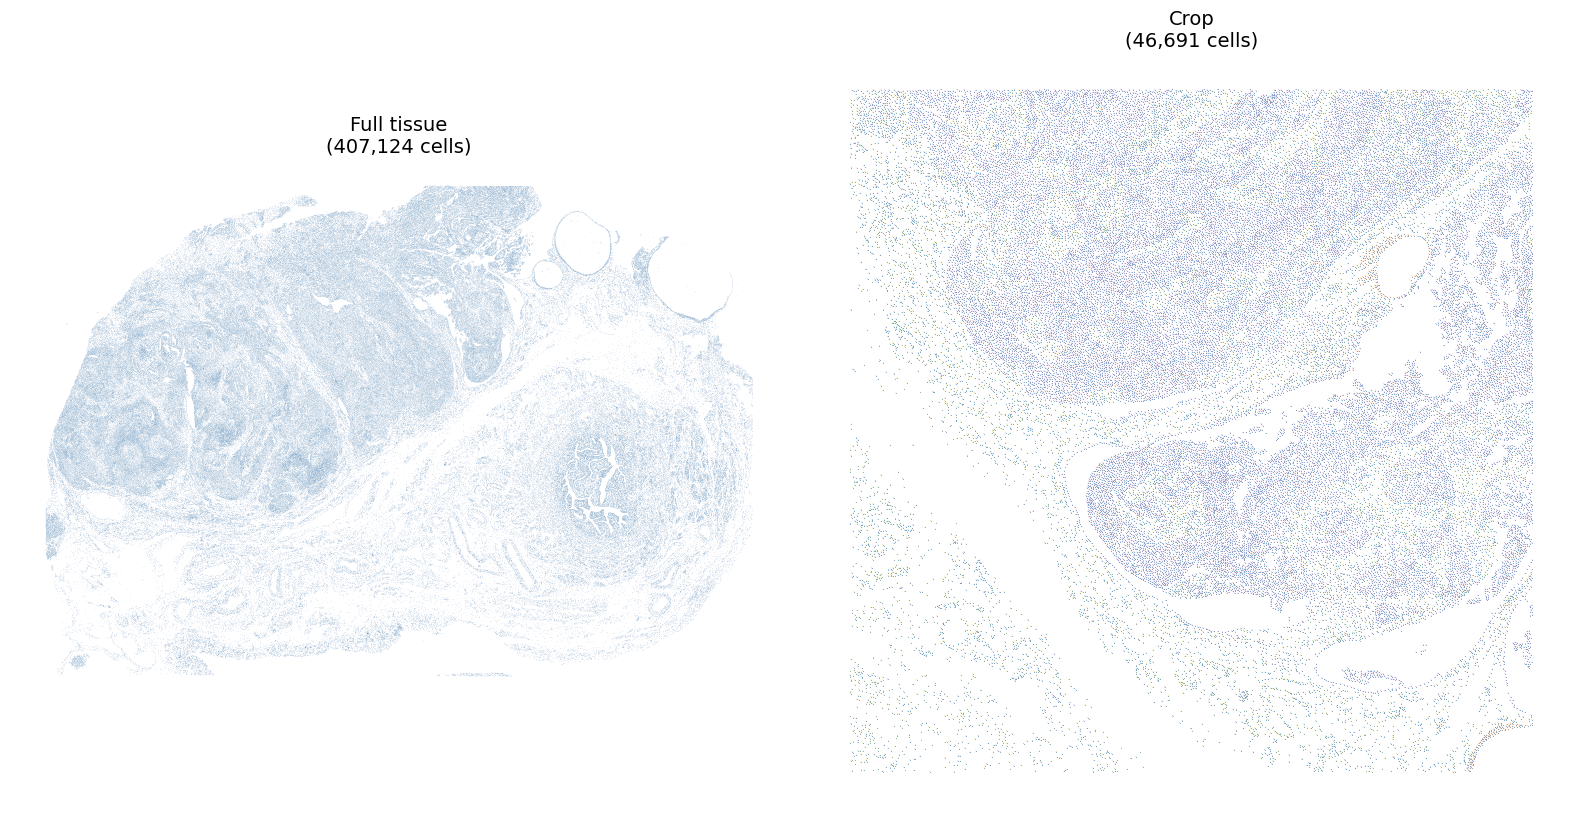

In [6]:
# visualizing two crops
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- full tissue ---
coords_full = adata_full.obsm['spatial']
axes[0].scatter(
    coords_full[:, 0], coords_full[:, 1],
    s=0.1, c='steelblue', alpha=0.3, linewidths=0
)
axes[0].set_title(f"Full tissue\n({adata_full.n_obs:,} cells)", fontsize=14)
axes[0].set_aspect('equal')
axes[0].invert_yaxis()
axes[0].axis('off')

# --- crop ---
coords_crop = adata_crop.obsm['spatial']
axes[1].scatter(
    coords_crop[:, 0], coords_crop[:, 1],
    s=0.5, c='steelblue', alpha=0.5, linewidths=0
)

# color by cell type if available
scatter = axes[1].scatter(
    coords_crop[:, 0], coords_crop[:, 1],
    s=0.5,
    c=pd.Categorical(adata_crop.obs['major_celltype']).codes,
    cmap='tab10', alpha=0.5, linewidths=0
)
axes[1].set_title(f"Crop\n({adata_crop.n_obs:,} cells)", fontsize=14)
axes[1].set_aspect('equal')
axes[1].invert_yaxis()
axes[1].axis('off')

plt.tight_layout()
plt.savefig("spatial_overview.png", dpi=150, bbox_inches='tight')
plt.show()

Creating a crop mask so we can split between training and test

In [7]:
# get crop cell ids
crop_ids = set(adata_crop.obs['cell_id'].values)

# create mask on full adata
crop_mask = adata_full.obs_names.isin(crop_ids)

adata_train = adata_full[~crop_mask].copy()
adata_test  = adata_full[crop_mask].copy()

# save both
adata_train.write_h5ad("/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_train.h5ad")
adata_test.write_h5ad("/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_test.h5ad")

print("\nSaved train and test adata")


Saved train and test adata


In [8]:
# check cell type distribution in each split
print("=== TRAIN cell types ===")
print(adata_train.obs['cell_type'].value_counts())

print("\n=== TEST cell types ===")
print(adata_test.obs['cell_type'].value_counts())

=== TRAIN cell types ===
cell_type
Tumor Cells                             86172
Smooth Muscle Cells                     59381
Proliferative Tumor Cells               40510
SOX2-OT+ Tumor Cells                    38630
Tumor Associated Fibroblasts            35623
Stromal Associated Fibroblasts          23305
Macrophages                             22316
Stromal Associated Endothelial Cells    16857
VEGFA+ Tumor Cells                       9821
T and NK Cells                           9035
Pericytes                                3875
Tumor Associated Endothelial Cells       3111
Fallopian Tube Epithelium                3001
Inflammatory Tumor Cells                 2075
Ciliated Epithelial Cells                1737
Urothelial-like Cells                    1636
Unassigned                               1600
Malignant Cells Lining Cyst              1235
Name: count, dtype: int64

=== TEST cell types ===
cell_type
Tumor Cells                             17435
Proliferative Tumor Cells     

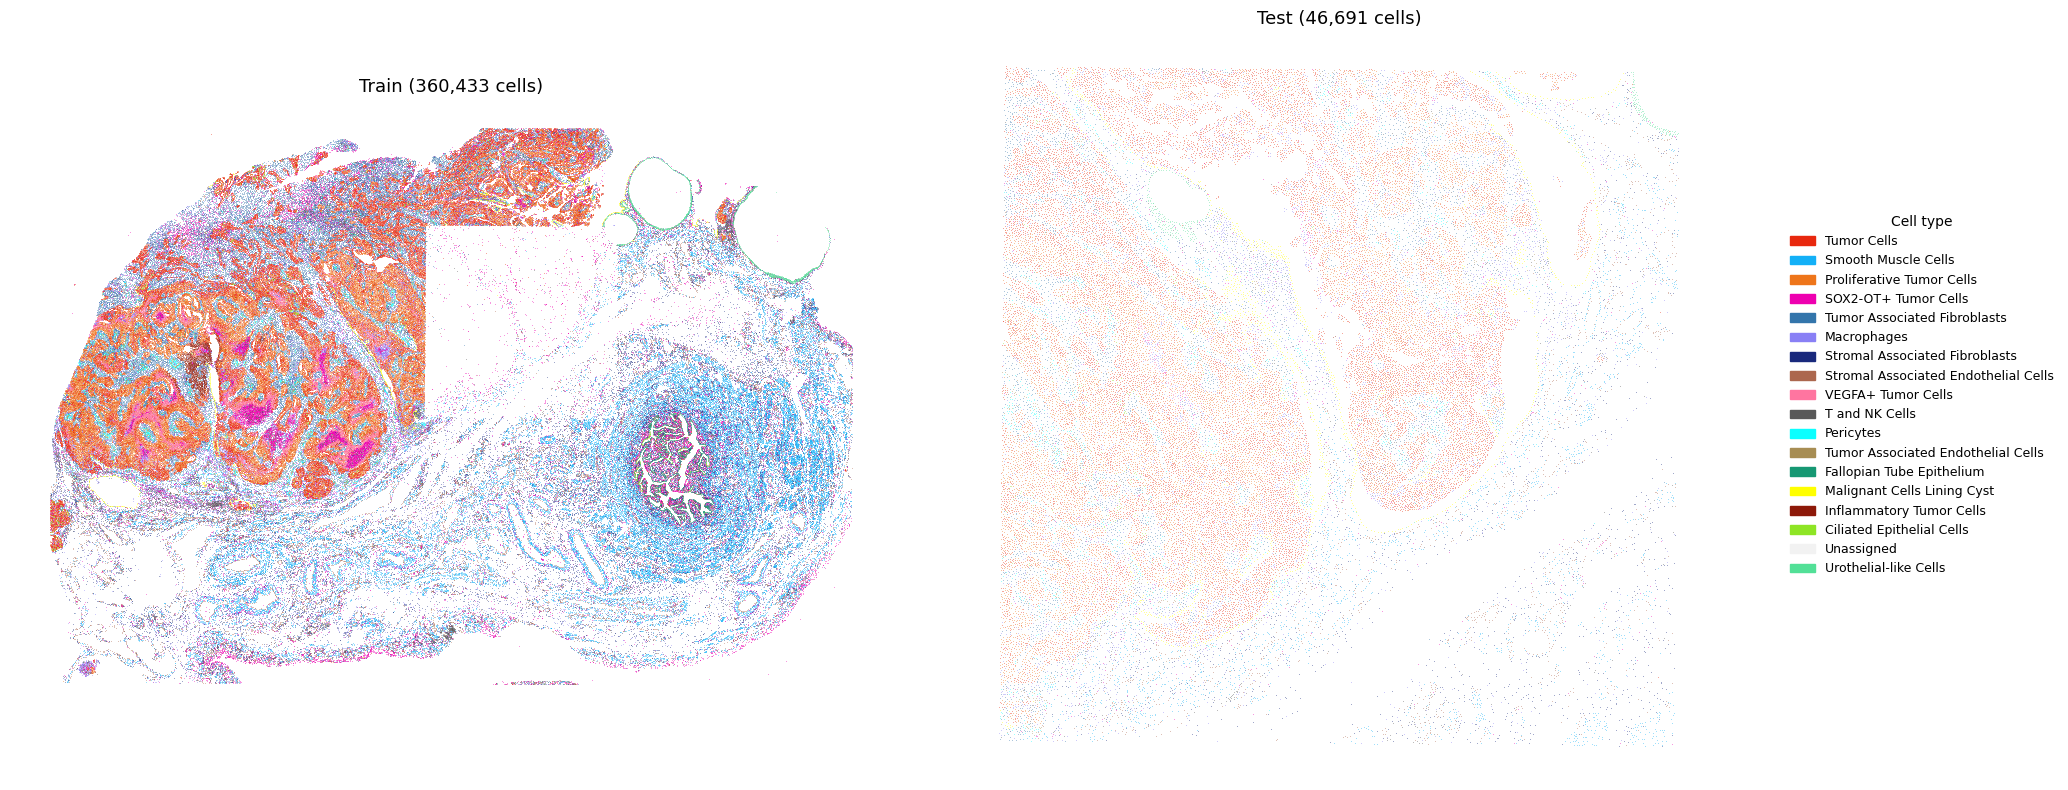

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# --- shared color map from cell_groups ---
color_map = cell_groups.groupby('group')['color'].first().to_dict()

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ordered by total count
all_types = adata_full.obs['cell_type'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, adata, title in [
    (axes[0], adata_train, f"Train ({adata_train.n_obs:,} cells)"),
    (axes[1], adata_test,  f"Test ({adata_test.n_obs:,} cells)")
]:
    coords = adata.obsm['spatial']
    cell_types = adata.obs['cell_type'].values
    
    for ct in all_types:
        mask = cell_types == ct
        if mask.sum() == 0:
            continue
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            s=0.3,
            c=color_map.get(ct, '#aaaaaa'),
            alpha=0.5,
            linewidths=0
        )
    
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')

# shared legend
patches = [
    mpatches.Patch(color=color_map.get(ct, '#aaaaaa'), label=ct)
    for ct in all_types
]
fig.legend(
    handles=patches,
    loc='center right',
    fontsize=9,
    frameon=False,
    title='Cell type',
    title_fontsize=10,
    bbox_to_anchor=(1.15, 0.5)
)

plt.tight_layout()
plt.savefig("spatial_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

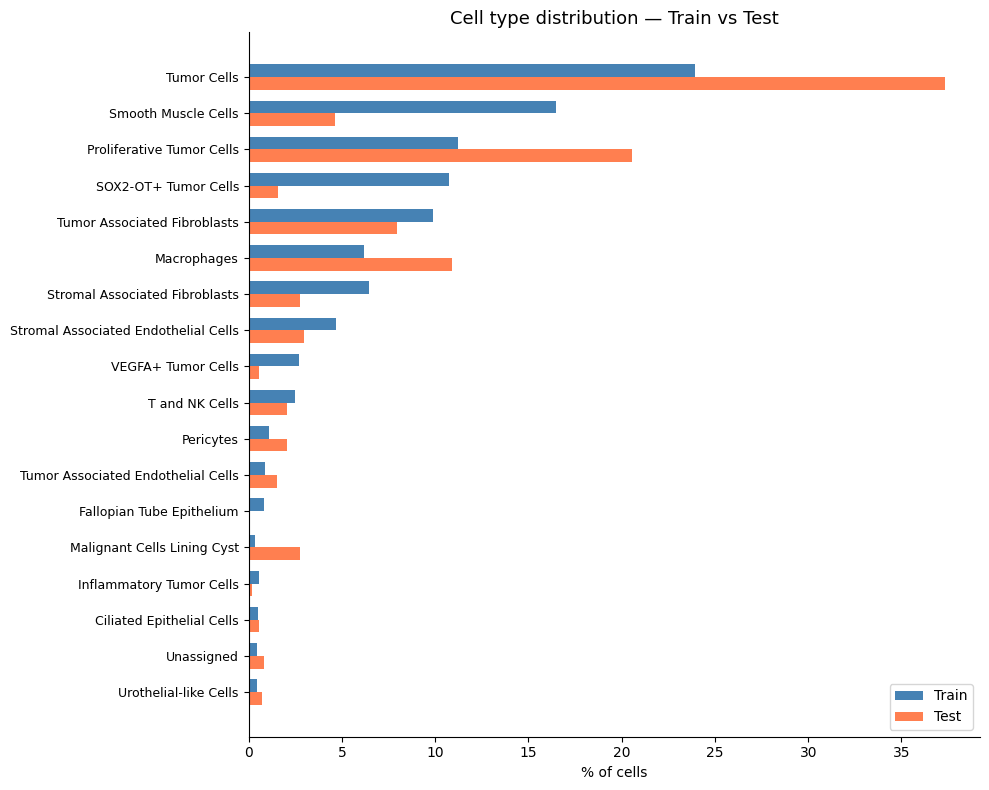

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

train_props = (adata_train.obs['cell_type'].value_counts() / 
               adata_train.n_obs * 100).reindex(all_types).fillna(0)
test_props  = (adata_test.obs['cell_type'].value_counts()  / 
               adata_test.n_obs  * 100).reindex(all_types).fillna(0)

x = np.arange(len(all_types))
width = 0.35

ax.barh(x - width/2, train_props.values, width,
        color='steelblue', label='Train', edgecolor='none')

ax.barh(x + width/2, test_props.values, width,
        color='coral', label='Test', edgecolor='none')

ax.set_yticks(x)
ax.set_yticklabels(all_types, fontsize=9)
ax.set_xlabel("% of cells")
ax.set_title("Cell type distribution — Train vs Test", fontsize=13)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("celltype_distribution.png", dpi=150, bbox_inches='tight')
plt.show()